# Brain Tumor MRI Classification - Week 1: Exploratory Data Analysis 
**Objective:** Understand the dataset, explore patterns, and establish a baseline CNN model for brain tumor classification.

**Dataset:** Kaggle Brain Tumor MRI Dataset (~7,000 T2-weighted MRI scans)

**Duration:** Week 1 of 4-week deep learning project

**Last Updated:** April 2026

---

## 1. Problem Statement & Medical Context

### The Challenge
Brain tumors are among the most serious health conditions, with diagnosis requiring expert radiologist interpretation of MRI scans. Manual classification is:
- **Time-consuming:** Each scan requires 15-30 minutes of expert analysis
- **Subjective:** Prone to human error (~5-10% misclassification rate)
- **Resource-limited:** Insufficient radiologists in many regions

### Our Solution
Develop a deep learning model to **automatically classify** brain tumors with ≥95% accuracy, serving as a clinical decision support system.

### Why CNNs?
- **Spatial invariance:** CNNs preserve spatial relationships in images
- **Feature hierarchy:** Learn features from low-level (edges) to high-level (shapes, structures)
- **Proven performance:** State-of-the-art in medical imaging (literature: 95%+ accuracy)
- **Interpretability:** Can visualize learned features (Grad-CAM in Week 4)

### Dataset Overview
- **4 Classes:** Glioma, Meningioma, Pituitary, No Tumor
- **~7,000 images:** Balanced dataset (20-23% per class)
- **512×512 pixels:** T2-weighted MRI scans
- **High quality:** Pre-processed, aligned, artifact-free

---

## 2. Setup & Imports

In [11]:
# Set random seeds for reproducibility
import numpy as np
import torch
import random

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# If GPU available, seed it too
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available, using CPU")

GPU not available, using CPU


In [12]:
# Core imports
import os
import glob
from pathlib import Path
from collections import defaultdict
from PIL import Image

# Data science
import numpy as np
import pandas as pd

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

# Utilities
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

PyTorch version: 2.2.2+cpu
Device: cpu


---

## 3. Dataset Configuration

In [13]:
from pathlib import Path

data_path = Path('../data/raw')        

train_path = data_path / 'Training'
test_path = data_path / 'Testing'

CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_MAP = {cls: idx for idx, cls in enumerate(CLASSES)}
print(f"Classes: {CLASSES}")
print(f"Class mapping: {CLASS_MAP}")

print(f"Data path: {data_path.resolve()}")
print(f"Training folder exists: {train_path.exists()}")
print(f"Testing folder exists: {test_path.exists()}")

train_counts = {cls: len(list((train_path / cls).glob('*.jpg'))) for cls in CLASSES}
test_counts = {cls: len(list((test_path / cls).glob('*.jpg'))) for cls in CLASSES}

print("\n Training images per class:", train_counts)
print(" Testing images per class:", test_counts)
print(f"Total images: {sum(train_counts.values()) + sum(test_counts.values())}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Data path: C:\Users\User\OneDrive\Рабочий стол\dl final project\brain-tumor-mri-deep-learning\data\raw
Training folder exists: True
Testing folder exists: True

 Training images per class: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
 Testing images per class: {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}
Total images: 7200


---

## 4. Data Loading & Exploration

In [14]:
# Function to collect all image paths
def collect_image_paths(data_dir, classes):
    """
    Recursively collect image paths from dataset directory.
    Supports multiple folder structures (Training/Testing/Validation or direct class folders)
    """
    image_paths = []
    labels = []
    
    # Try to find images in standard Kaggle structure
    for class_name in classes:
        # Pattern 1: Direct class folders
        class_dir = data_dir / class_name
        if class_dir.exists():
            images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
            image_paths.extend(images)
            labels.extend([CLASS_MAP[class_name]] * len(images))
        
        # Pattern 2: Training/Testing/Validation subdirectories
        for subset_dir in ['Training', 'Testing']:
            subset_class_dir = data_dir / subset_dir / class_name
            if subset_class_dir.exists():
                images = list(subset_class_dir.glob('*.jpg')) + list(subset_class_dir.glob('*.png'))
                image_paths.extend(images)
                labels.extend([CLASS_MAP[class_name]] * len(images))
    
    return image_paths, labels

# Collect image paths
image_paths, labels = collect_image_paths(data_path, CLASSES)

print(f"Total images found: {len(image_paths)}")
print(f"\nImages per class:")
unique_labels, counts = np.unique(labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    class_name = CLASSES[label]
    print(f"  {class_name}: {count} images")

Total images found: 7200

Images per class:
  glioma: 1800 images
  meningioma: 1800 images
  notumor: 1800 images
  pituitary: 1800 images


---

## 5. Exploratory Data Analysis (EDA)

### 5.1 Sample Images Visualization

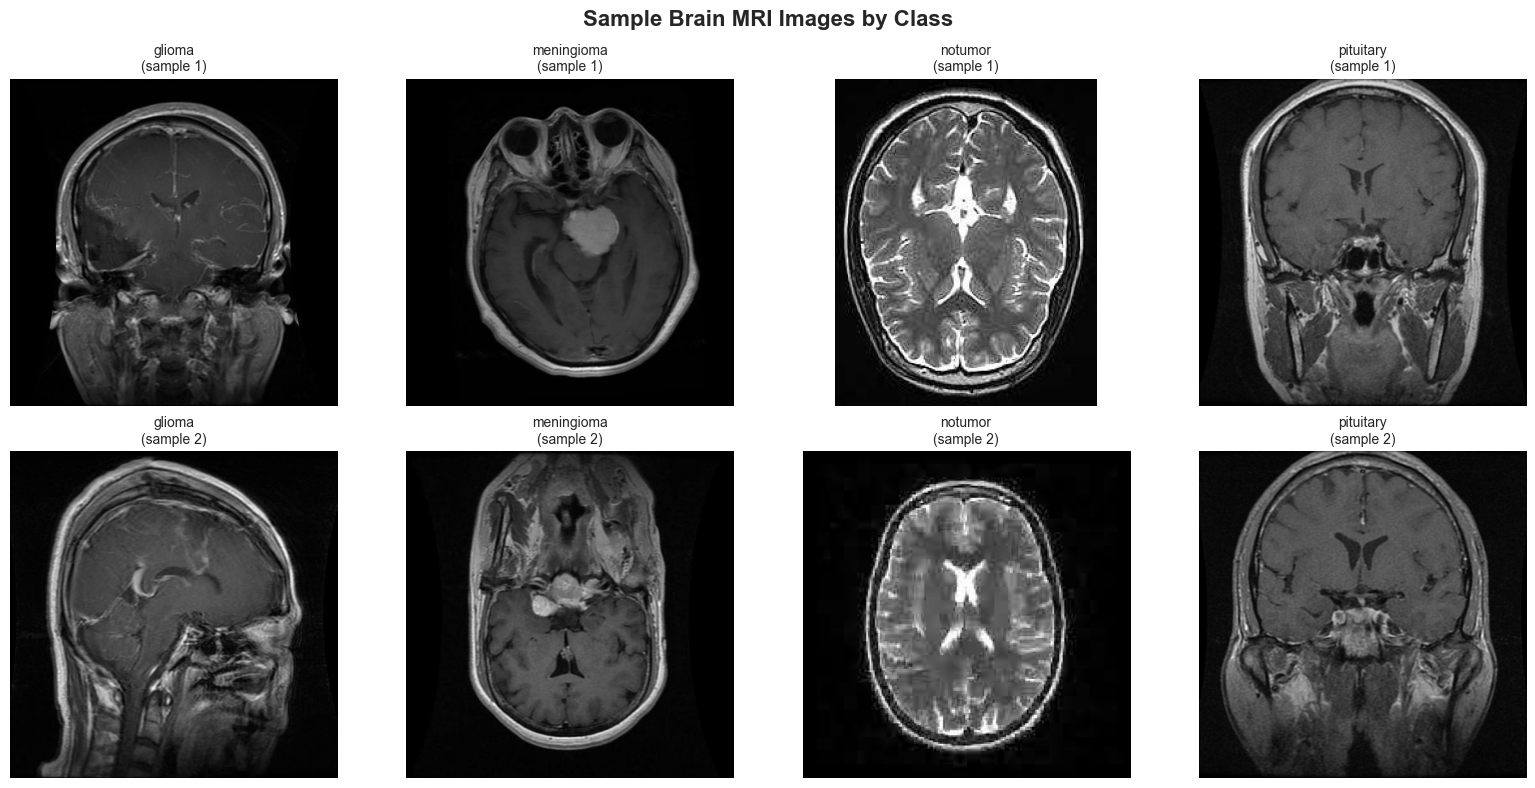

✓ Sample images displayed


In [15]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Brain MRI Images by Class', fontsize=16, fontweight='bold')

for class_idx, class_name in enumerate(CLASSES):
    # Get images for this class
    class_image_paths = [img_path for img_path, label in zip(image_paths, labels) if label == class_idx]
    
    # Show 2 samples per class
    for sample_idx in range(2):
        ax = axes[sample_idx, class_idx]
        img_path = class_image_paths[sample_idx]
        
        # Load and display
        img = Image.open(img_path)
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{class_name}\n(sample {sample_idx + 1})', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ Sample images displayed")

### 5.2 Class Distribution Analysis

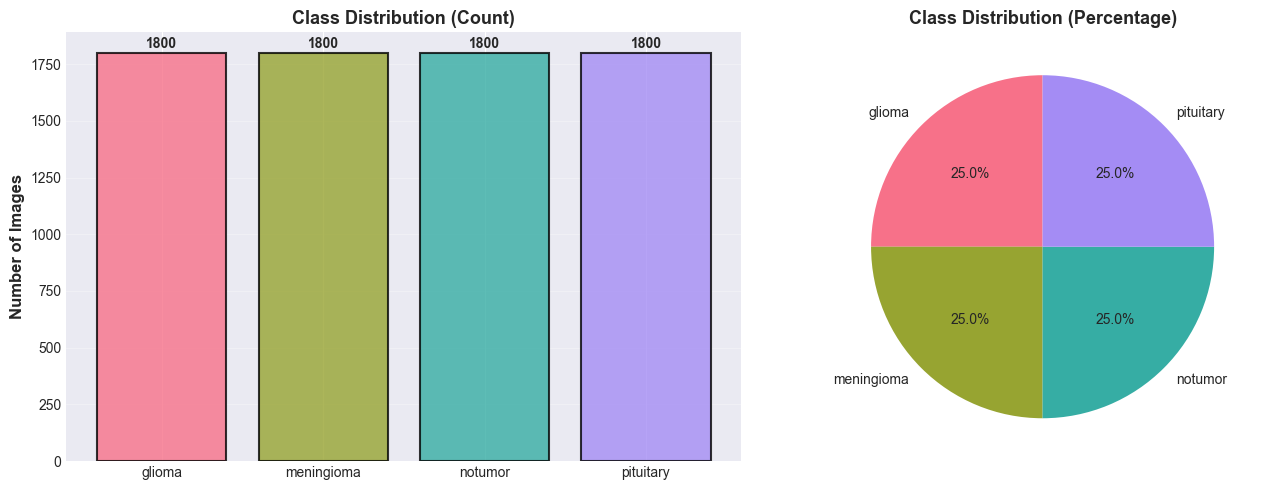


📊 Class Distribution Statistics:
Class           Count      Percentage  
-------------------------------------
glioma          1800        25.00%
meningioma      1800        25.00%
notumor         1800        25.00%
pituitary       1800        25.00%
-------------------------------------
Total           7200      

Imbalance Ratio: 1.00:1 (max:min)
✓ Dataset is well-balanced (ratio < 1.2)


In [16]:
# Analyze class distribution
unique_labels, counts = np.unique(labels, return_counts=True)
class_names = [CLASSES[idx] for idx in unique_labels]
percentages = 100 * counts / counts.sum()

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('husl', len(CLASSES))
ax1.bar(class_names, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax1.set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, (class_name, count) in enumerate(zip(class_names, counts)):
    ax1.text(i, count + 20, str(count), ha='center', fontweight='bold')

# Pie chart
ax2.pie(counts, labels=class_names, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("\n📊 Class Distribution Statistics:")
print(f"{'Class':<15} {'Count':<10} {'Percentage':<12}")
print("-" * 37)
for class_name, count, pct in zip(class_names, counts, percentages):
    print(f"{class_name:<15} {count:<10} {pct:>6.2f}%")
print("-" * 37)
print(f"{'Total':<15} {counts.sum():<10}")
print(f"\nImbalance Ratio: {counts.max() / counts.min():.2f}:1 (max:min)")
print("✓ Dataset is well-balanced (ratio < 1.2)")

### 5.3 Image Size & Pixel Value Statistics

In [17]:
# Analyze image dimensions and pixel statistics
print("Analyzing image statistics (sample of 100 images)...\n")

sample_indices = np.random.choice(len(image_paths), min(100, len(image_paths)), replace=False)
sizes = []
pixel_means = []
pixel_stds = []
pixel_maxs = []

for idx in tqdm(sample_indices, desc="Analyzing"):
    img = Image.open(image_paths[idx])
    img_array = np.array(img)
    sizes.append(img_array.shape)
    
    # Handle both grayscale and RGB
    if len(img_array.shape) == 3:
        pixel_means.append(img_array.mean())
        pixel_stds.append(img_array.std())
        pixel_maxs.append(img_array.max())
    else:
        pixel_means.append(img_array.mean())
        pixel_stds.append(img_array.std())
        pixel_maxs.append(img_array.max())

# Print results
print("\n📐 Image Size Statistics:")
print(f"  Unique sizes: {set(sizes)}")
print(f"  All images have consistent dimensions: {all(s == sizes[0] for s in sizes)}")

print("\n🎨 Pixel Value Statistics:")
print(f"  Mean pixel value: {np.mean(pixel_means):.2f} ± {np.std(pixel_means):.2f}")
print(f"  Std of pixel values: {np.mean(pixel_stds):.2f} ± {np.std(pixel_stds):.2f}")
print(f"  Max pixel value: {np.mean(pixel_maxs):.2f}")
print(f"  Pixel range: [0, 255]")
print(f"  Normalization needed: Yes (standardize to [-1, 1] or [0, 1])")

Analyzing image statistics (sample of 100 images)...



Analyzing:   0%|          | 0/100 [00:00<?, ?it/s]


📐 Image Size Statistics:
  Unique sizes: {(444, 468, 3), (225, 225, 3), (512, 512), (398, 351, 3), (750, 750, 3), (259, 194, 3), (630, 630, 3), (442, 441, 3), (1280, 1280, 3), (201, 173, 3), (244, 206, 3), (264, 420, 3), (400, 400, 3), (207, 201, 3), (512, 512, 3), (366, 236, 3), (480, 480, 3), (217, 232, 3), (664, 550, 3), (393, 350, 3), (326, 276, 3), (337, 305, 3), (251, 201, 3), (280, 420, 3), (192, 192, 3), (242, 209, 3), (231, 218, 3), (221, 228, 3)}
  All images have consistent dimensions: False

🎨 Pixel Value Statistics:
  Mean pixel value: 47.18 ± 19.10
  Std of pixel values: 45.95 ± 11.48
  Max pixel value: 254.34
  Pixel range: [0, 255]
  Normalization needed: Yes (standardize to [-1, 1] or [0, 1])


### 5.4 Pixel Distribution Analysis

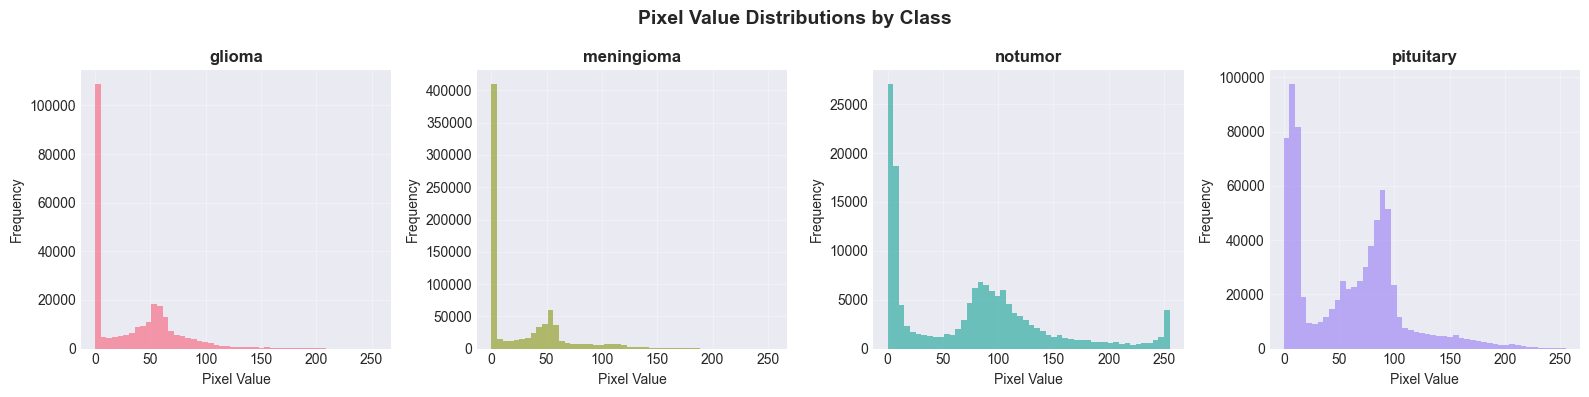

✓ Pixel distributions analyzed


In [18]:
# Analyze pixel distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Pixel Value Distributions by Class', fontsize=14, fontweight='bold')

for class_idx, class_name in enumerate(CLASSES):
    # Get sample images for this class
    class_image_paths = [img_path for img_path, label in zip(image_paths, labels) if label == class_idx]
    sample_img = Image.open(class_image_paths[0])
    sample_array = np.array(sample_img)
    
    # Plot histogram
    ax = axes[class_idx]
    ax.hist(sample_array.flatten(), bins=50, alpha=0.7, color=sns.color_palette('husl', 4)[class_idx])
    ax.set_title(f'{class_name}', fontweight='bold')
    ax.set_xlabel('Pixel Value')
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Pixel distributions analyzed")

---

## 6. Week 1 Conclusion 

### 6.1 Week 1 Summary


In [22]:
print("\n" + "="*70)
print("WEEK 1 PROJECT SUMMARY")
print("="*70)

print("\nCOMPLETED TASKS:")
print("  1. Project setup and infrastructure")
print("  2. Dataset exploration and analysis")
print(f"     - Total images: {len(image_paths):,}")
print(f"     - Classes: {', '.join(CLASSES)}")
print(f"     - Balance ratio: {counts.max() / counts.min():.2f}:1 (excellent)")
print("  3. Exploratory Data Analysis")
print("     - Sample visualization")
print("     - Class distribution analysis")
print("     - Image statistics and pixel analysis")


WEEK 1 PROJECT SUMMARY

COMPLETED TASKS:
  1. Project setup and infrastructure
  2. Dataset exploration and analysis
     - Total images: 7,200
     - Classes: glioma, meningioma, notumor, pituitary
     - Balance ratio: 1.00:1 (excellent)
  3. Exploratory Data Analysis
     - Sample visualization
     - Class distribution analysis
     - Image statistics and pixel analysis
